In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Dataset loading

In [32]:
df = pd.read_csv('cell2celltrain_Small_6k.csv',na_values='?')
df.head()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,Churn
0,30.88,436.0,30.0,0.25,1.0,0.0,-112.0,0.1,11.0,0.3,...,8,No,0,150.0,No,2-High,Other,Other,Yes,Yes
1,44.83,172.0,45.0,0.00,0.0,0.0,-12.0,-15.5,0.3,0.3,...,7,No,0,80.0,No,2-High,Suburban,Other,No,No
2,42.63,838.0,50.0,0.74,5.0,0.0,28.0,-2.6,4.7,6.3,...,0,No,0,130.0,No,5-Low,Suburban,Other,NaN,No
3,33.49,358.0,50.0,0.00,0.0,0.0,-16.0,0.0,1.0,4.0,...,8,No,0,150.0,No,2-High,Town,Other,Yes,No
4,60.94,1276.0,60.0,4.70,0.0,0.0,-188.0,0.2,5.7,19.7,...,0,No,0,30.0,No,5-Low,Other,Other,NaN,No


In [12]:
df.describe()

,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,RetentionCalls,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,HandsetPrice
count,6359.000000,6359.000000,6359.000000,6359.000000,6359.000000,6359.000000,6338.000000,6338.000000,6380.000000,6380.000000,...,6380.000000,6380.000000,6270.000000,6270.000000,6380.000000,6380.000000,6380.000000,6380.000000,6380.000000,2781.000000
mean,59.130495,531.206794,47.092625,0.973702,40.096556,1.154804,-9.410066,-0.923541,6.176693,4.068072,...,1.560031,382.086207,31.128230,21.175120,0.036364,0.017555,0.052665,4.319592,0.055956,83.531104
std,43.571333,548.862582,24.073053,3.084585,94.725405,5.464669,253.659969,37.558534,9.329839,9.756478,...,0.889754,261.987590,22.231625,24.098821,0.200940,0.138313,0.257298,3.144514,0.339910,62.879709
min,-6.170000,0.000000,-6.000000,0.000000,0.000000,0.000000,-2458.000000,-552.400000,0.000000,0.000000,...,1.000000,-3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,33.595000,157.000000,30.000000,0.000000,0.000000,0.000000,-82.000000,-7.200000,0.700000,0.000000,...,1.000000,202.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000
50%,48.560000,366.000000,45.000000,0.250000,2.000000,0.000000,-4.000000,-0.300000,3.000000,1.000000,...,1.000000,329.000000,36.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,60.000000
75%,71.980000,719.500000,60.000000,0.990000,40.000000,0.200000,67.000000,1.800000,7.700000,3.700000,...,2.000000,513.000000,48.000000,42.000000,0.000000,0.000000,0.000000,7.000000,0.000000,150.000000
max,776.270000,7359.000000,400.000000,159.390000,2278.000000,144.600000,2398.000000,741.100000,166.300000,144.700000,...,10.000000,1695.000000,98.000000,98.000000,4.000000,3.000000,7.000000,9.000000,9.000000,500.000000


In [33]:
na_percnt_cols = df.isna().sum()/len(df)*100
na_percnt_cols

MonthlyRevenue                0.329154
MonthlyMinutes                0.329154
TotalRecurringCharge          0.329154
DirectorAssistedCalls         0.329154
OverageMinutes                0.329154
RoamingCalls                  0.329154
PercChangeMinutes             0.658307
PercChangeRevenues            0.658307
DroppedCalls                  0.000000
BlockedCalls                  0.000000
UnsweredCalls                 0.000000
CustomerCareCalls             0.000000
ThreewayCalls                 0.000000
ReceivedCalls                 0.000000
OutboundCalls                 0.000000
InboundCalls                  0.000000
PeakCallsInOut                0.000000
OffPeakCallsInOut             0.000000
DroppedBlockedCalls           0.000000
CallForwardingCalls           0.000000
CallWaitingCalls              0.000000
MonthsInService               0.000000
UniqueSubs                    0.000000
ActiveSubs                    0.000000
ServiceArea                   0.047022
Handsets                 

### Data Pre-processing

In [34]:
# Imputing columns with missing values percentage between 0 to 10% with mode
impcols = df.columns.values[(na_percnt_cols > 0) & (na_percnt_cols < 10)].tolist()
for c in impcols:
    df[c] = df[c].fillna(value=df[c].mode()[0])
# Dropping the columns that contains high percentage of missing values typically over 10%
df = df.drop(columns=['Homeownership','HandsetPrice','MaritalStatus'])

In [104]:
len(impcols)

11

In [16]:
df.isna().sum()/len(df)*100

MonthlyRevenue               0.0
MonthlyMinutes               0.0
TotalRecurringCharge         0.0
DirectorAssistedCalls        0.0
OverageMinutes               0.0
RoamingCalls                 0.0
PercChangeMinutes            0.0
PercChangeRevenues           0.0
DroppedCalls                 0.0
BlockedCalls                 0.0
UnsweredCalls                0.0
CustomerCareCalls            0.0
ThreewayCalls                0.0
ReceivedCalls                0.0
OutboundCalls                0.0
InboundCalls                 0.0
PeakCallsInOut               0.0
OffPeakCallsInOut            0.0
DroppedBlockedCalls          0.0
CallForwardingCalls          0.0
CallWaitingCalls             0.0
MonthsInService              0.0
UniqueSubs                   0.0
ActiveSubs                   0.0
ServiceArea                  0.0
Handsets                     0.0
HandsetModels                0.0
CurrentEquipmentDays         0.0
AgeHH1                       0.0
AgeHH2                       0.0
ChildrenIn

In [35]:
df = df.drop(columns='ServiceArea')

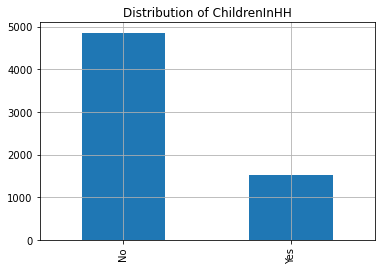

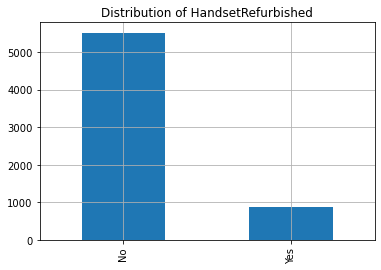

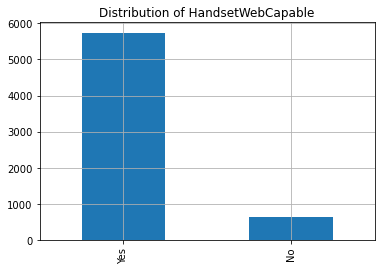

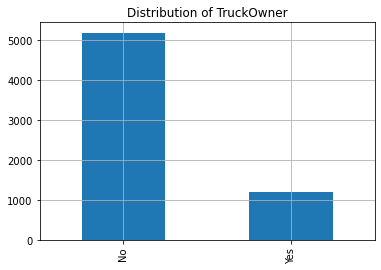

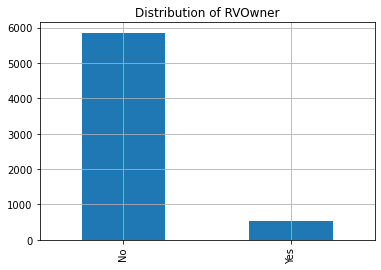

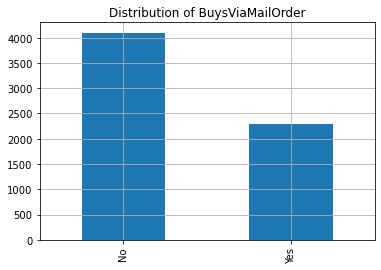

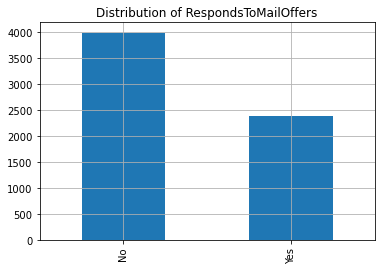

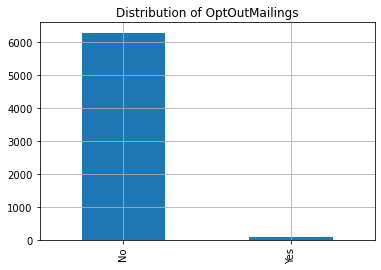

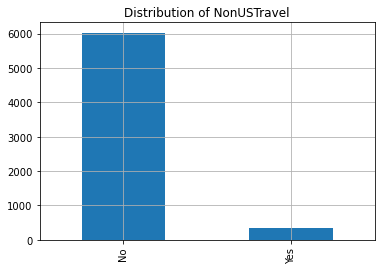

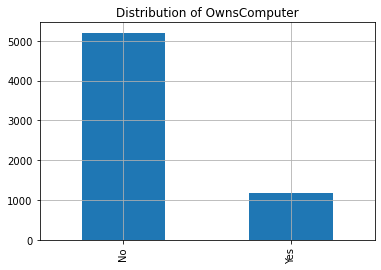

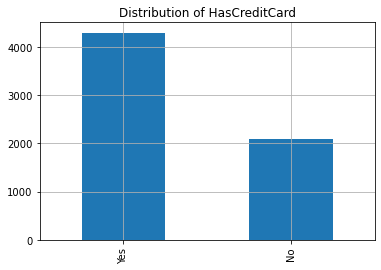

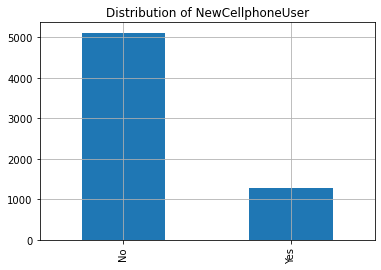

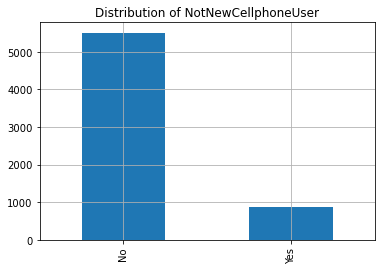

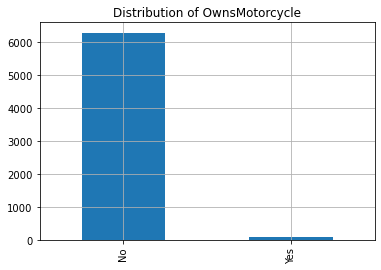

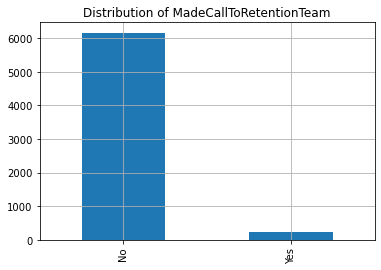

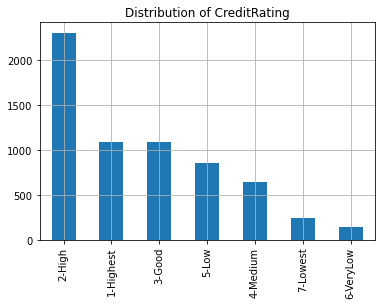

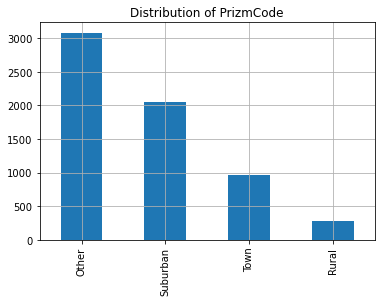

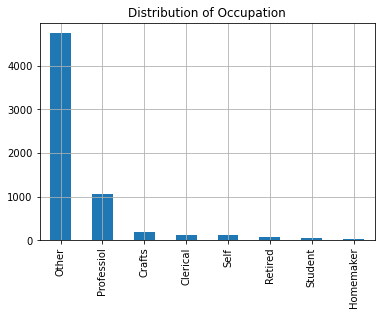

In [102]:
# Visualization of features
cat_features = df.select_dtypes(include='object').columns.values.tolist()[:-1]
for c in cat_features:
    df[c].value_counts().plot.bar()
    plt.grid()
    plt.title('Distribution of '+c)
    plt.show()

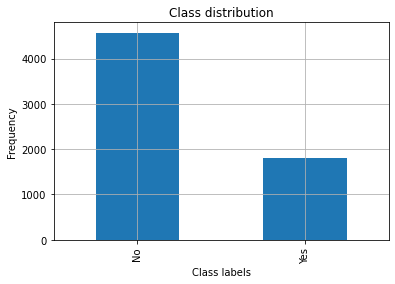

In [103]:
df['Churn'].value_counts().plot.bar()
plt.grid()
plt.xlabel('Class labels')
plt.ylabel('Frequency')
plt.title('Class distribution')
plt.show()

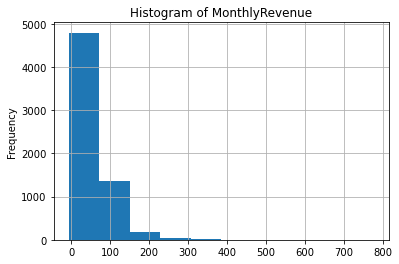

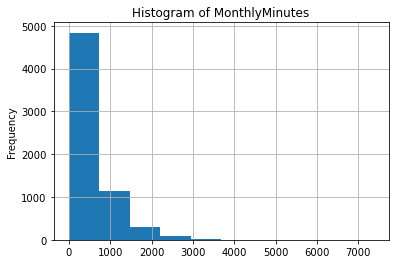

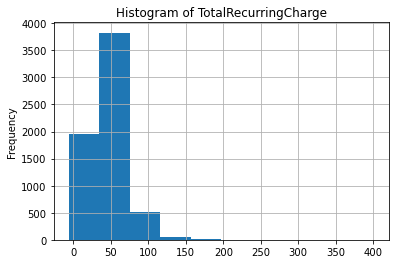

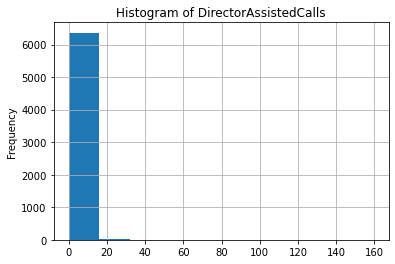

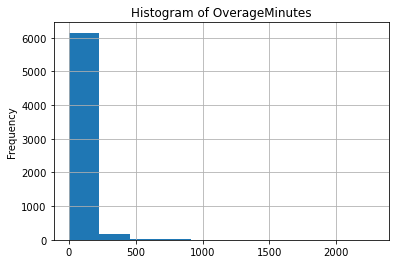

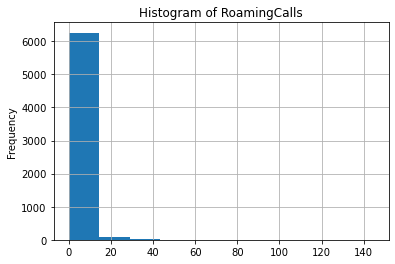

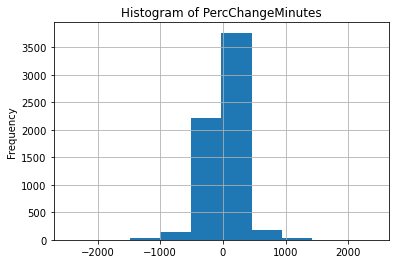

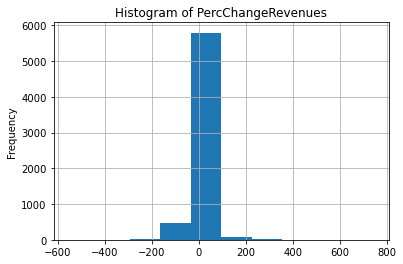

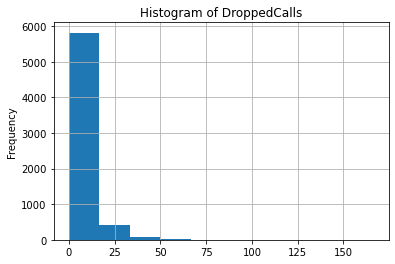

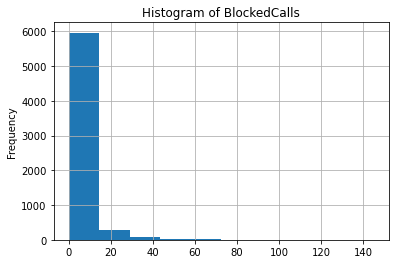

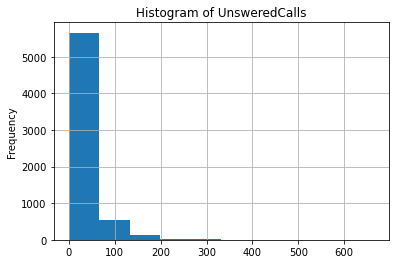

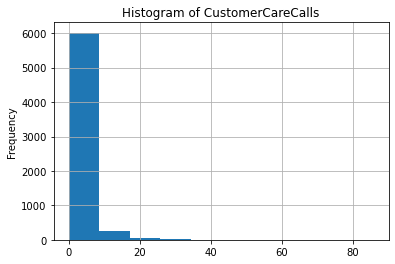

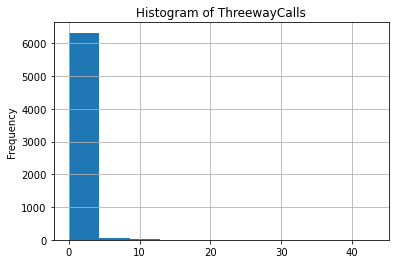

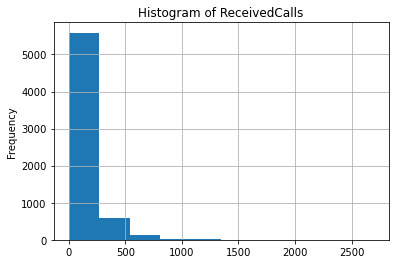

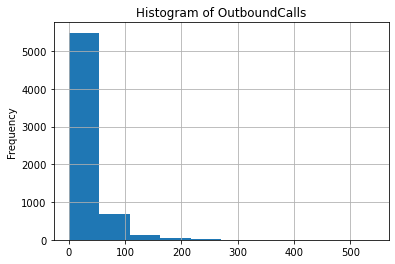

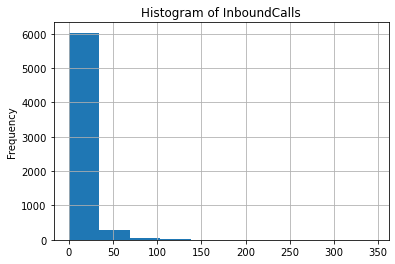

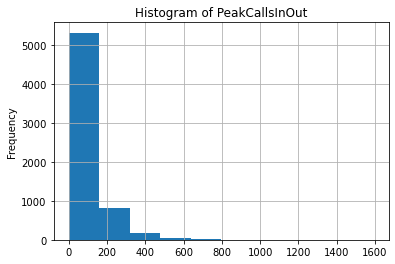

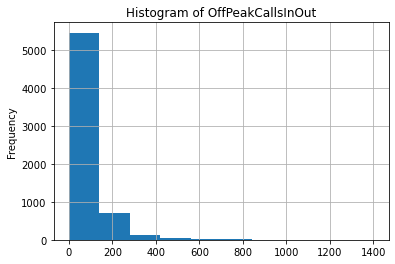

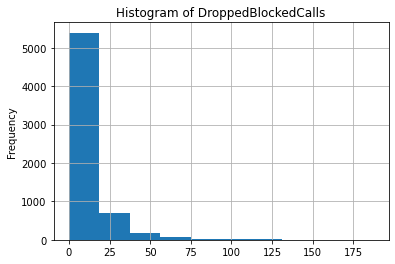

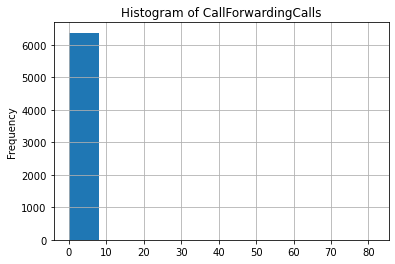

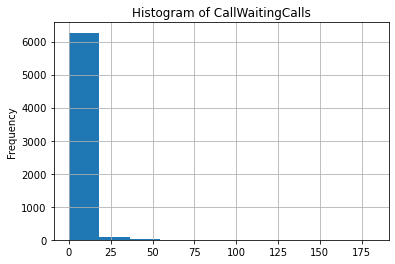

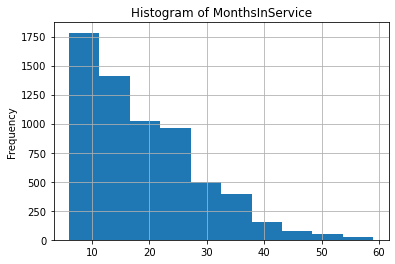

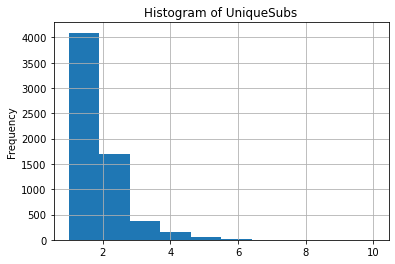

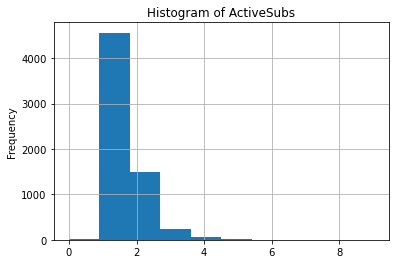

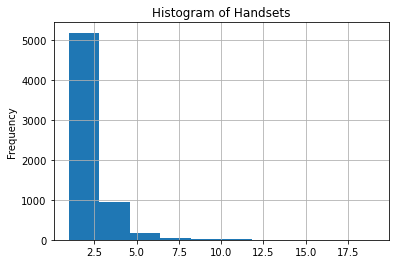

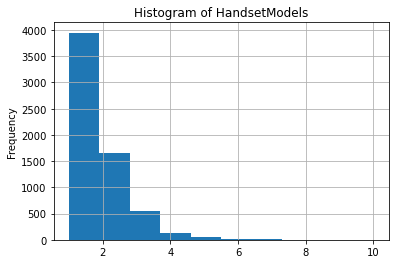

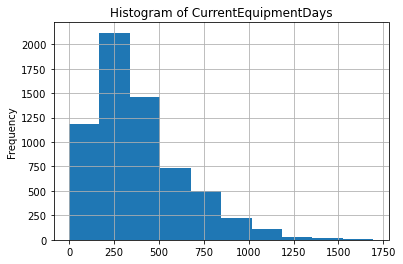

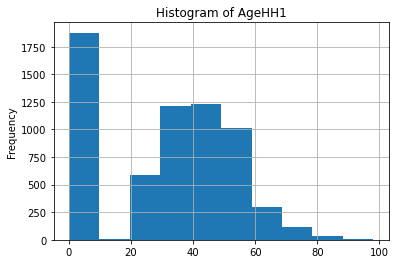

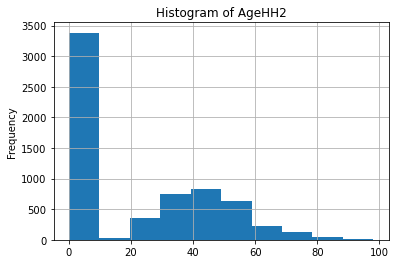

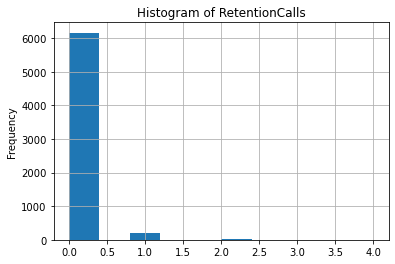

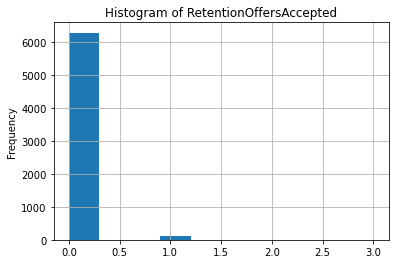

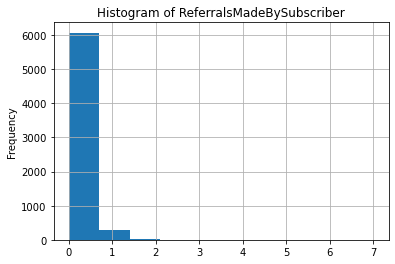

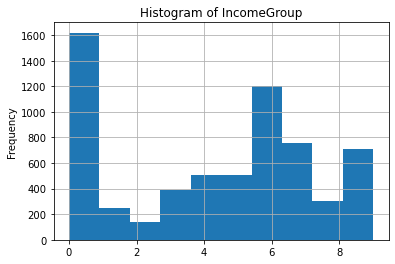

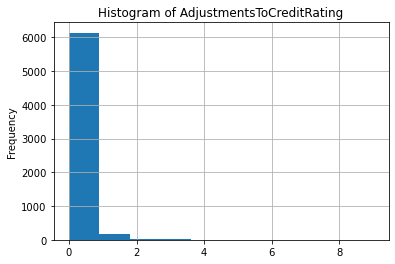

In [45]:
num_features = df.select_dtypes(exclude='object').columns.values.tolist()
for n in num_features:
    df[n].plot.hist()
    plt.title('Histogram of '+n)
    plt.grid()
    plt.show()

In [51]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import Normalizer
from sklearn.compose import ColumnTransformer
X = df.drop(columns='Churn')
y = df['Churn']
ct = ColumnTransformer([("norm1", Normalizer(norm='l1'), num_features),\
                        ("ohenc", OneHotEncoder(handle_unknown='ignore'), cat_features)],remainder='drop')
Xtr = ct.fit_transform(X)
Xtr.shape

(6380, 83)

In [61]:
# stochastic optimization for feature selection
from numpy import mean
from numpy.random import rand
from numpy.random import choice
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
 
# objective function is the cross validation accuracy
def objective(X, y, subset):
	# convertion into column indexes
	ix = [i for i, x in enumerate(subset) if x]
    # checking if there is a column in dataset
	if len(ix) == 0:
		return 0.0
	# selection of columns
	X_new = X[:, ix]
	# Decision tree model is used to fit with the features
	model = DecisionTreeClassifier()
	# evaluation of model on selected set to get scores for cv =3
	scores = cross_val_score(model, X_new, y, scoring='accuracy', cv=3, n_jobs=-1)
	# summarizing the scores by mean
	result = mean(scores)
	return result, ix
 
# mutation operation
def mutate(solution, p_mutate):
	# intializing child with input features
	child = solution.copy()
	for i in range(len(child)):
		# checking for mutation
		if rand() < p_mutate:
			# flipping the inclusion
			child[i] = not child[i]
	return child
 
# implementation of hill climbing algorithm
def hillclimbing(X, y, objective, n_iter, p_mutate):
	# initial solution
	solution = choice([True, False], size=X.shape[1])
	# objective value of intial solution 
	solution_eval, ix = objective(X, y, solution)
	# running the hill climbling algorithm
	for i in range(n_iter):
		# each step of hill climb
		candidate = mutate(solution, p_mutate)
		# evaluating the candidate point
		candidate_eval, ix = objective(X, y, candidate)
		# checking if current solution is better
		if candidate_eval >= solution_eval:
			# storing when new solution is better
			solution, solution_eval = candidate, candidate_eval
		# printing the scores at each iteration
		print('Iteration %d: f(%s) = %f' % (i+1, len(ix), solution_eval))
	return solution, solution_eval
 

# define the total iterations
n_iter = 20
# mutation rate: the probability to include a column or exclude
p_mut = 0.1
# perform the hill climbing search
subset, score = hillclimbing(Xtr, y, objective, n_iter, p_mut)
# convert into column indexes
ix = [i for i, x in enumerate(subset) if x]
print('Done!')
print('Best: f(%d) = %f' % (len(ix), score))

Iteration 1: f(43) = 0.603293
Iteration 2: f(41) = 0.605485
Iteration 3: f(45) = 0.605485
Iteration 4: f(37) = 0.605485
Iteration 5: f(42) = 0.618653
Iteration 6: f(43) = 0.618653
Iteration 7: f(39) = 0.618653
Iteration 8: f(44) = 0.618653
Iteration 9: f(40) = 0.618653
Iteration 10: f(39) = 0.618653
Iteration 11: f(42) = 0.618653
Iteration 12: f(42) = 0.618653
Iteration 13: f(45) = 0.618653
Iteration 14: f(42) = 0.618653
Iteration 15: f(44) = 0.618653
Iteration 16: f(47) = 0.618653
Iteration 17: f(46) = 0.618653
Iteration 18: f(47) = 0.618653
Iteration 19: f(41) = 0.618653
Iteration 20: f(46) = 0.618653
Done!
Best: f(42) = 0.618653


In [62]:
Xmod = Xtr[:,subset]
Xmod.shape

(6380, 42)

## Machine learning model fitting and evaluation with feature selection

In [112]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Xmod, y, test_size=0.2, random_state=673)
print('Train set feature shape:',X_train.shape)
print('Test set feature shape:',X_test.shape)

Train set feature shape: (5104, 42)
Test set feature shape: (1276, 42)


### Gaussian Naive Bayes model fitting and evaluation

Gaussian Naive Bayes model parameters:
 {'priors': None, 'var_smoothing': 1e-09}


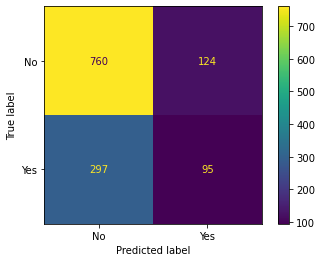

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.72      0.86      0.78       884
         Yes       0.43      0.24      0.31       392

    accuracy                           0.67      1276
   macro avg       0.58      0.55      0.55      1276
weighted avg       0.63      0.67      0.64      1276

Matthews correlation coefficient: 0.1249


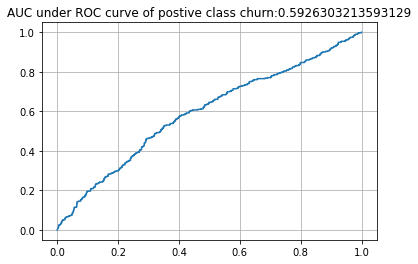

In [65]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

nbmodel = GaussianNB()
nbmodel.fit(X_train,y_train)
print('Gaussian Naive Bayes model parameters:\n',nbmodel.get_params())
ypreds = nbmodel.predict(X_test)
probs = nbmodel.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(nbmodel,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of postive class churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

### Multi-layer perceptron neural network model fitting and evaluation

MLP neural network model parameters:
 {'activation': 'relu', 'alpha': 1e-06, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (70, 30), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 784, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


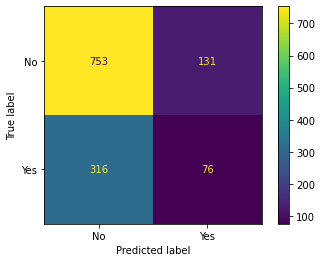

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.70      0.85      0.77       884
         Yes       0.37      0.19      0.25       392

    accuracy                           0.65      1276
   macro avg       0.54      0.52      0.51      1276
weighted avg       0.60      0.65      0.61      1276

Matthews correlation coefficient: 0.0572


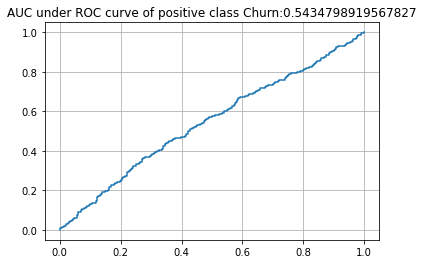

In [76]:
from sklearn.neural_network import MLPClassifier
mlpmodel = MLPClassifier(random_state=784,hidden_layer_sizes=(70,30),solver='adam',alpha=1e-6, max_iter=1000).fit(X_train, y_train)
print('MLP neural network model parameters:\n',mlpmodel.get_params())
ypreds = mlpmodel.predict(X_test)
probs = mlpmodel.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(mlpmodel,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of positive class Churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

### Decision tree classifier model fitting and evaluation

Decision tree model parameters:
 {'ccp_alpha': 0.001, 'class_weight': {'No': 1, 'Yes': 2}, 'criterion': 'gini', 'max_depth': None, 'max_features': 30, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_impurity_split': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'presort': 'deprecated', 'random_state': 506, 'splitter': 'best'}


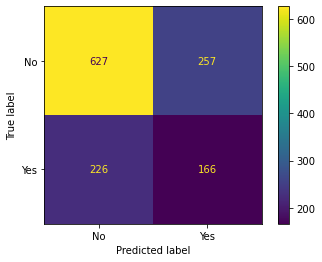

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.74      0.71      0.72       884
         Yes       0.39      0.42      0.41       392

    accuracy                           0.62      1276
   macro avg       0.56      0.57      0.56      1276
weighted avg       0.63      0.62      0.63      1276

Matthews correlation coefficient: 0.1301


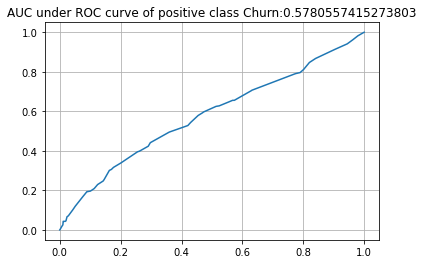

In [113]:
from sklearn.tree import DecisionTreeClassifier
dtreemodel = DecisionTreeClassifier(random_state=506,ccp_alpha=1e-3,min_samples_split=4,max_features=30,\
                                    class_weight={'No':1,'Yes':2}).fit(X_train,y_train)
print('Decision tree model parameters:\n',dtreemodel.get_params())
ypreds = dtreemodel.predict(X_test)
probs = dtreemodel.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(dtreemodel,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of positive class Churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

### Support vector machine classifier model fitting and evaluation

Support vector machine classifier model parameters:
 {'memory': None, 'steps': [('standardscaler', StandardScaler()), ('svc', SVC(C=10, gamma='auto', probability=True))], 'verbose': False, 'standardscaler': StandardScaler(), 'svc': SVC(C=10, gamma='auto', probability=True), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'svc__C': 10, 'svc__break_ties': False, 'svc__cache_size': 200, 'svc__class_weight': None, 'svc__coef0': 0.0, 'svc__decision_function_shape': 'ovr', 'svc__degree': 3, 'svc__gamma': 'auto', 'svc__kernel': 'rbf', 'svc__max_iter': -1, 'svc__probability': True, 'svc__random_state': None, 'svc__shrinking': True, 'svc__tol': 0.001, 'svc__verbose': False}


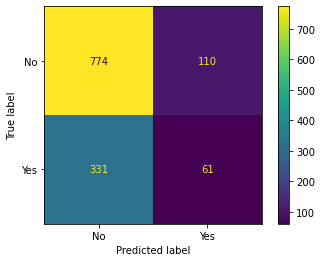

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.70      0.88      0.78       884
         Yes       0.36      0.16      0.22       392

    accuracy                           0.65      1276
   macro avg       0.53      0.52      0.50      1276
weighted avg       0.59      0.65      0.61      1276

Matthews correlation coefficient: 0.0422


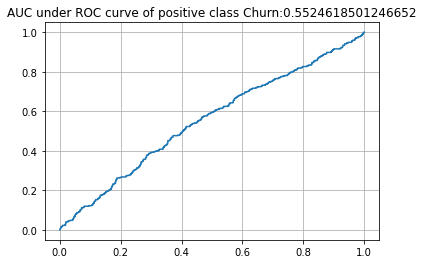

In [83]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svc = make_pipeline(StandardScaler(), SVC(gamma='auto',probability=True,C=10)).fit(X_train, y_train)
print('Support vector machine classifier model parameters:\n',svc.get_params())
ypreds = svc.predict(X_test)
probs = svc.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(svc,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of positive class Churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

## Evaluation results without feature selection

In [106]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(Xtr, y, test_size=0.2, random_state=673)
print('Train set feature shape:',X_train.shape)
print('Test set feature shape:',X_test.shape)

Train set feature shape: (5104, 83)
Test set feature shape: (1276, 83)


### Gaussian naive bayes without feature selection

Gaussian Naive Bayes model parameters:
 {'priors': None, 'var_smoothing': 1e-09}


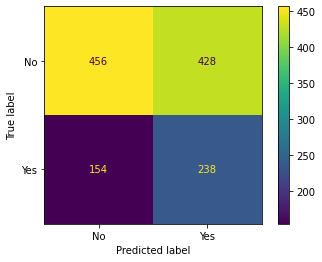

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.75      0.52      0.61       884
         Yes       0.36      0.61      0.45       392

    accuracy                           0.54      1276
   macro avg       0.55      0.56      0.53      1276
weighted avg       0.63      0.54      0.56      1276

Matthews correlation coefficient: 0.1136


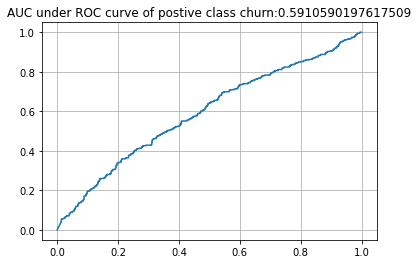

In [107]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef

nbmodel = GaussianNB()
nbmodel.fit(X_train,y_train)
print('Gaussian Naive Bayes model parameters:\n',nbmodel.get_params())
ypreds = nbmodel.predict(X_test)
probs = nbmodel.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(nbmodel,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of postive class churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

### MLP neural network without feature selection

MLP neural network model parameters:
 {'activation': 'relu', 'alpha': 1e-06, 'batch_size': 'auto', 'beta_1': 0.9, 'beta_2': 0.999, 'early_stopping': False, 'epsilon': 1e-08, 'hidden_layer_sizes': (70, 30), 'learning_rate': 'constant', 'learning_rate_init': 0.001, 'max_fun': 15000, 'max_iter': 1000, 'momentum': 0.9, 'n_iter_no_change': 10, 'nesterovs_momentum': True, 'power_t': 0.5, 'random_state': 784, 'shuffle': True, 'solver': 'adam', 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': False, 'warm_start': False}


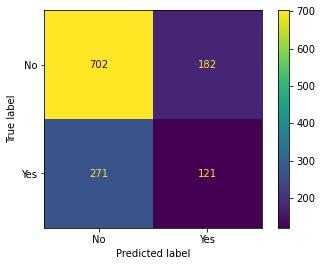

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.72      0.79      0.76       884
         Yes       0.40      0.31      0.35       392

    accuracy                           0.64      1276
   macro avg       0.56      0.55      0.55      1276
weighted avg       0.62      0.64      0.63      1276

Matthews correlation coefficient: 0.1114


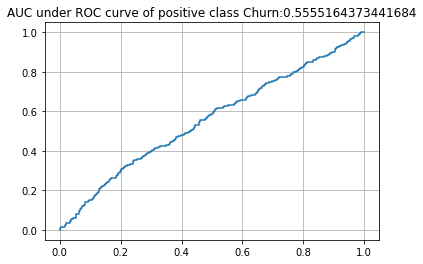

In [108]:
from sklearn.neural_network import MLPClassifier
mlpmodel = MLPClassifier(random_state=784,hidden_layer_sizes=(70,30),solver='adam',alpha=1e-6, max_iter=1000).fit(X_train, y_train)
print('MLP neural network model parameters:\n',mlpmodel.get_params())
ypreds = mlpmodel.predict(X_test)
probs = mlpmodel.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(mlpmodel,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of positive class Churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

### Decision tree classifier without feature selection

Decision tree model parameters:
 {'ccp_alpha': 0.001, 'class_weight': {'No': 1, 'Yes': 2}, 'criterion': 'gini', 'max_depth': None, 'max_features': 30, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_impurity_split': None, 'min_samples_leaf': 1, 'min_samples_split': 4, 'min_weight_fraction_leaf': 0.0, 'presort': 'deprecated', 'random_state': 506, 'splitter': 'best'}


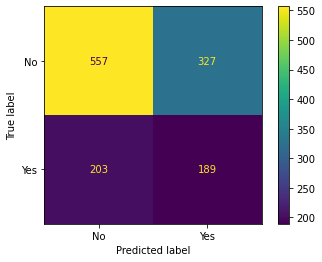

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.73      0.63      0.68       884
         Yes       0.37      0.48      0.42       392

    accuracy                           0.58      1276
   macro avg       0.55      0.56      0.55      1276
weighted avg       0.62      0.58      0.60      1276

Matthews correlation coefficient: 0.1055


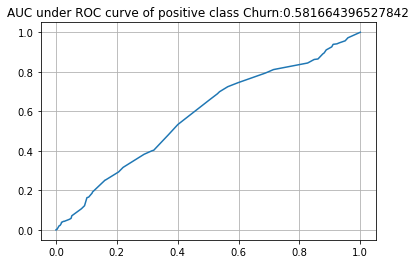

In [111]:
from sklearn.tree import DecisionTreeClassifier
dtreemodel = DecisionTreeClassifier(random_state=506,ccp_alpha=1e-3,min_samples_split=4,max_features=30,\
                                    class_weight={'No':1,'Yes':2}).fit(X_train,y_train)
print('Decision tree model parameters:\n',dtreemodel.get_params())
ypreds = dtreemodel.predict(X_test)
probs = dtreemodel.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(dtreemodel,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of positive class Churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()

### Support vector machine classifier without feature selection

Support vector machine classifier model parameters:
 {'memory': None, 'steps': [('standardscaler', StandardScaler()), ('svc', SVC(C=10, gamma='auto', probability=True))], 'verbose': False, 'standardscaler': StandardScaler(), 'svc': SVC(C=10, gamma='auto', probability=True), 'standardscaler__copy': True, 'standardscaler__with_mean': True, 'standardscaler__with_std': True, 'svc__C': 10, 'svc__break_ties': False, 'svc__cache_size': 200, 'svc__class_weight': None, 'svc__coef0': 0.0, 'svc__decision_function_shape': 'ovr', 'svc__degree': 3, 'svc__gamma': 'auto', 'svc__kernel': 'rbf', 'svc__max_iter': -1, 'svc__probability': True, 'svc__random_state': None, 'svc__shrinking': True, 'svc__tol': 0.001, 'svc__verbose': False}


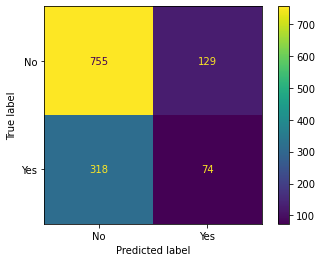

Classification report in test set: 
               precision    recall  f1-score   support

          No       0.70      0.85      0.77       884
         Yes       0.36      0.19      0.25       392

    accuracy                           0.65      1276
   macro avg       0.53      0.52      0.51      1276
weighted avg       0.60      0.65      0.61      1276

Matthews correlation coefficient: 0.0540


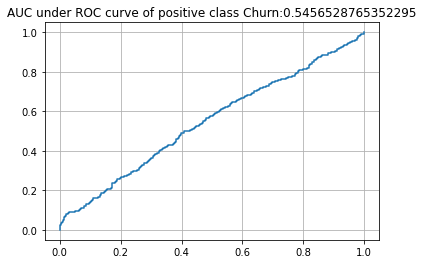

In [110]:
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
svc = make_pipeline(StandardScaler(), SVC(gamma='auto',probability=True,C=10)).fit(X_train, y_train)
print('Support vector machine classifier model parameters:\n',svc.get_params())
ypreds = svc.predict(X_test)
probs = svc.predict_proba(X_test)
fig, axes = plt.subplots()
plot_confusion_matrix(svc,X_test, y_test,ax=axes)
plt.show()
print('Classification report in test set: \n',classification_report(y_test,ypreds,\
                                                           labels = ['No','Yes']))
print('Matthews correlation coefficient: %.4f' %(matthews_corrcoef(y_test,ypreds)))
fpr, tpr, thresholds = roc_curve(y_test, probs[:,1], pos_label='Yes')
plt.plot(fpr,tpr)
plt.grid()
plt.title('AUC under ROC curve of positive class Churn:'+str(roc_auc_score(y_test,probs[:,1])))
plt.show()